# 03 Exploratory Data Analysis (EDA)

**Role:** Analysis Lead  
**Objective:** Identify patterns, trends, and correlations in the banking dataset to understand drivers of customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
# Load cleaned data
df = pd.read_csv('../data/churn_clean.csv')

# Standardize column names so the analysis code stays consistent
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df = df.rename(columns={
    'current_balance': 'current_balance',
    'prev_month_end_balance': 'previous_month_end_balance',
    'avg_balance_prev_q1': 'average_monthly_balance_prevq',
    'avg_balance_prev_q2': 'average_monthly_balance_prevq2',
    'current_month_credit': 'current_month_credit',
    'prev_month_credit': 'previous_month_credit',
    'current_month_debit': 'current_month_debit',
    'prev_month_debit': 'previous_month_debit',
})

df.head()



,vintage,age,gender,dependents,occupation,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevq,average_monthly_balance_prevq2,...,churn,last_transaction,transaction_year,transaction_month,transaction_day,no_transaction_flag,age_group,balance_segment,total_transactions,activity_level
0,2101,66,Male,0.0,self_employed,2,1458.71,1458.71,1458.71,1449.07,...,0,2019-05-21,2019.0,5.0,21.0,0,Senior,Medium,0.40,Low Activity
1,2348,35,Male,0.0,self_employed,2,5390.37,8704.66,7799.26,12419.41,...,0,2019-11-01,2019.0,11.0,1.0,0,Adult,Medium,5486.83,Moderate
2,2194,31,Male,0.0,salaried,2,3913.16,5815.29,4910.17,2815.94,...,0,NaN,NaN,NaN,NaN,1,Adult,Medium,6047.34,Moderate
3,2329,90,Male,0.0,self_employed,2,2291.91,2291.91,2084.54,1006.54,...,1,2019-08-06,2019.0,8.0,6.0,0,Senior,Medium,0.94,Low Activity
4,1579,42,Male,2.0,self_employed,3,927.72,1401.72,1643.31,1871.12,...,1,2019-11-03,2019.0,11.0,3.0,0,Middle Age,Low,588.95,Low Activity


## 1. Univariate Analysis

Exploring individual variables to understand their distribution.

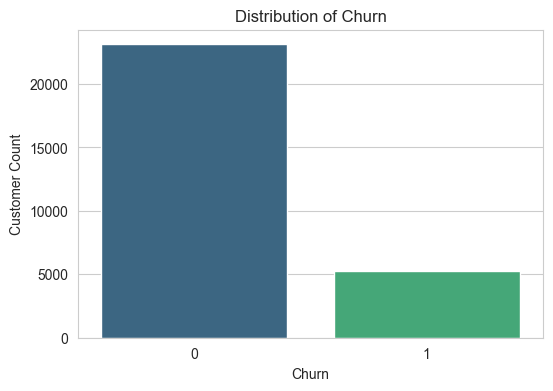

Overall Churn Rate: 18.53%
churn
Not Churned    23122
Churned         5260
Name: count, dtype: int64


In [3]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Customer Count')
plt.show()

churn_rate = df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(df['churn'].value_counts().rename({0: 'Not Churned', 1: 'Churned'}))



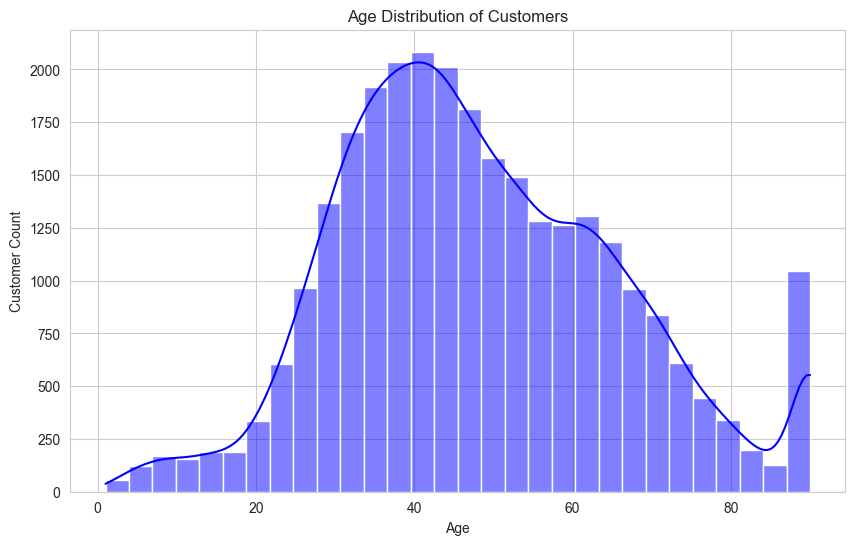

Age Summary:
count    28382.000000
mean        48.208336
std         17.807163
min          1.000000
25%         36.000000
50%         46.000000
75%         60.000000
max         90.000000
Name: age, dtype: float64


In [4]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.show()

print('Age Summary:')
print(df['age'].describe())



## 2. Bivariate Analysis

How does churn relate to other variables?

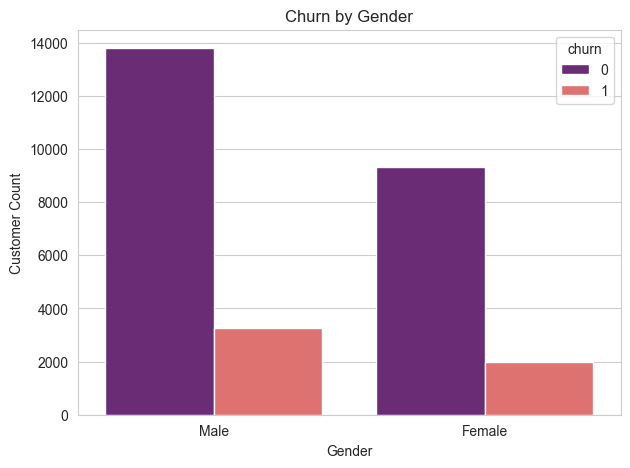

Churn Rate by Gender (%):
gender
Female    17.55
Male      19.18
Name: churn, dtype: float64


In [5]:
# Churn by Gender
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', hue='churn', data=df, palette='magma')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Count')
plt.show()

print('Churn Rate by Gender (%):')
print((df.groupby('gender')['churn'].mean() * 100).round(2))



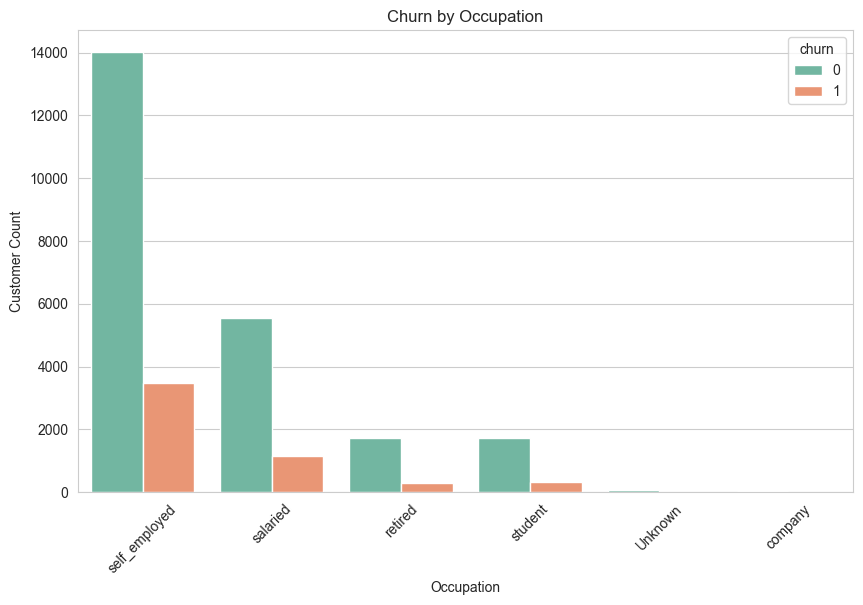

Churn Rate by Occupation (%):
occupation
self_employed    19.84
salaried         17.11
Unknown          16.25
student          15.74
retired          15.07
company          10.00
Name: churn, dtype: float64


In [6]:
# Churn by Occupation
plt.figure(figsize=(10, 6))
sns.countplot(x='occupation', hue='churn', data=df, palette='Set2')
plt.title('Churn by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)
plt.show()

print('Churn Rate by Occupation (%):')
print((df.groupby('occupation')['churn'].mean() * 100).sort_values(ascending=False).round(2))



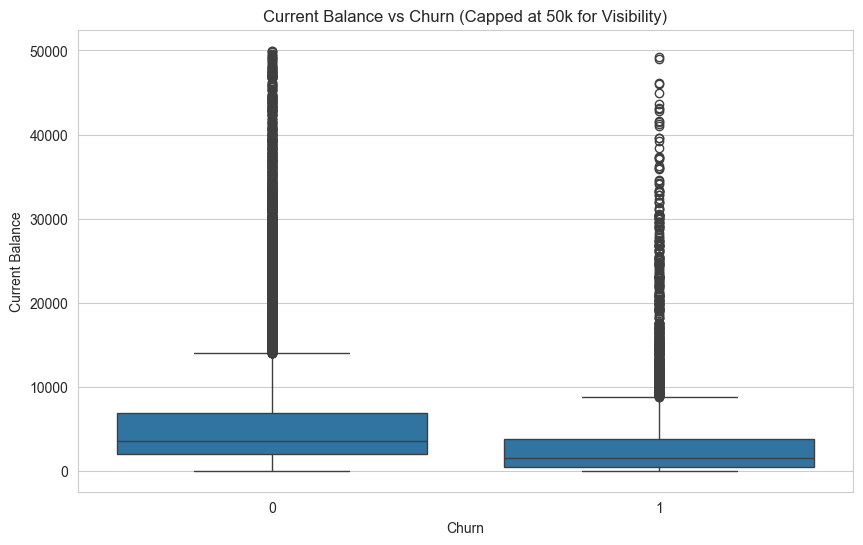

Current Balance by Churn:
          mean   median
churn                  
0      6734.15  3643.12
1      4202.91  1540.88


In [7]:
# Churn vs Current Balance
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='current_balance', data=df[df['current_balance'] < 50000])
plt.title('Current Balance vs Churn (Capped at 50k for Visibility)')
plt.xlabel('Churn')
plt.ylabel('Current Balance')
plt.show()

print('Current Balance by Churn:')
print(df.groupby('churn')['current_balance'].agg(['mean', 'median']).round(2))



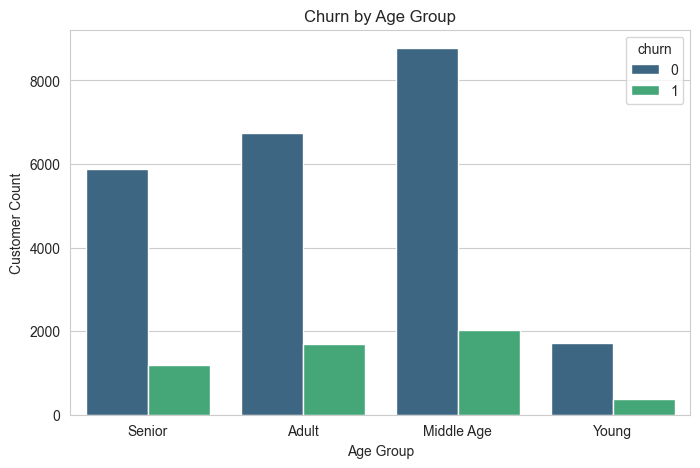

Churn Rate by Age Group (%):
age_group
Adult         19.98
Middle Age    18.79
Young         17.51
Senior        16.72
Name: churn, dtype: float64


In [8]:
# Churn by Age Group
plt.figure(figsize=(8, 5))
sns.countplot(x='age_group', hue='churn', data=df, palette='viridis')
plt.title('Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')
plt.show()

print('Churn Rate by Age Group (%):')
print((df.groupby('age_group')['churn'].mean() * 100).sort_values(ascending=False).round(2))



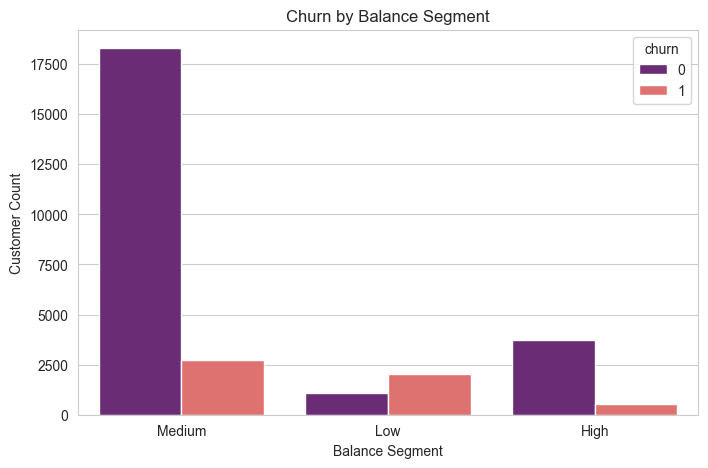

Churn Rate by Balance Segment (%):
balance_segment
Low       65.31
Medium    12.96
High      12.18
Name: churn, dtype: float64


In [9]:
# Churn by Balance Segment
plt.figure(figsize=(8, 5))
sns.countplot(x='balance_segment', hue='churn', data=df, palette='magma')
plt.title('Churn by Balance Segment')
plt.xlabel('Balance Segment')
plt.ylabel('Customer Count')
plt.show()

print('Churn Rate by Balance Segment (%):')
print((df.groupby('balance_segment')['churn'].mean() * 100).sort_values(ascending=False).round(2))



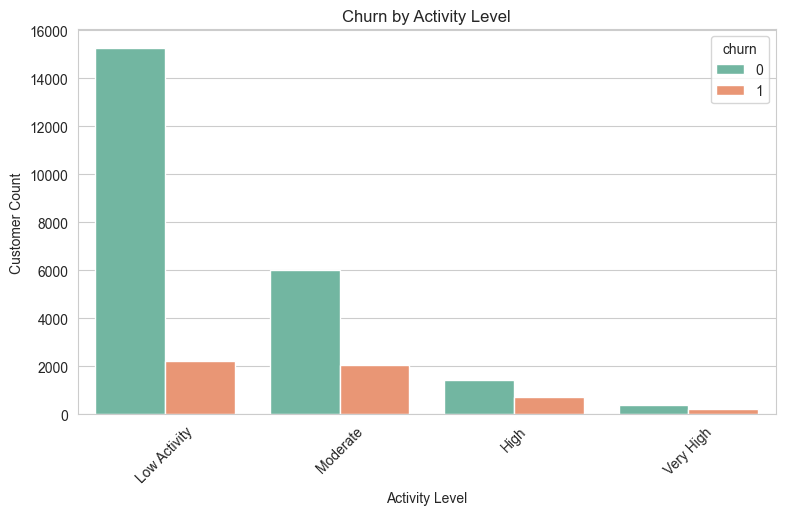

Churn Rate by Activity Level (%):
activity_level
Very High       38.37
High            33.96
Moderate        25.59
Low Activity    12.64
Name: churn, dtype: float64


In [10]:
# Churn by Activity Level
plt.figure(figsize=(9, 5))
sns.countplot(x='activity_level', hue='churn', data=df, palette='Set2')
plt.title('Churn by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)
plt.show()

print('Churn Rate by Activity Level (%):')
print((df.groupby('activity_level')['churn'].mean() * 100).sort_values(ascending=False).round(2))



## 3. Correlation Analysis

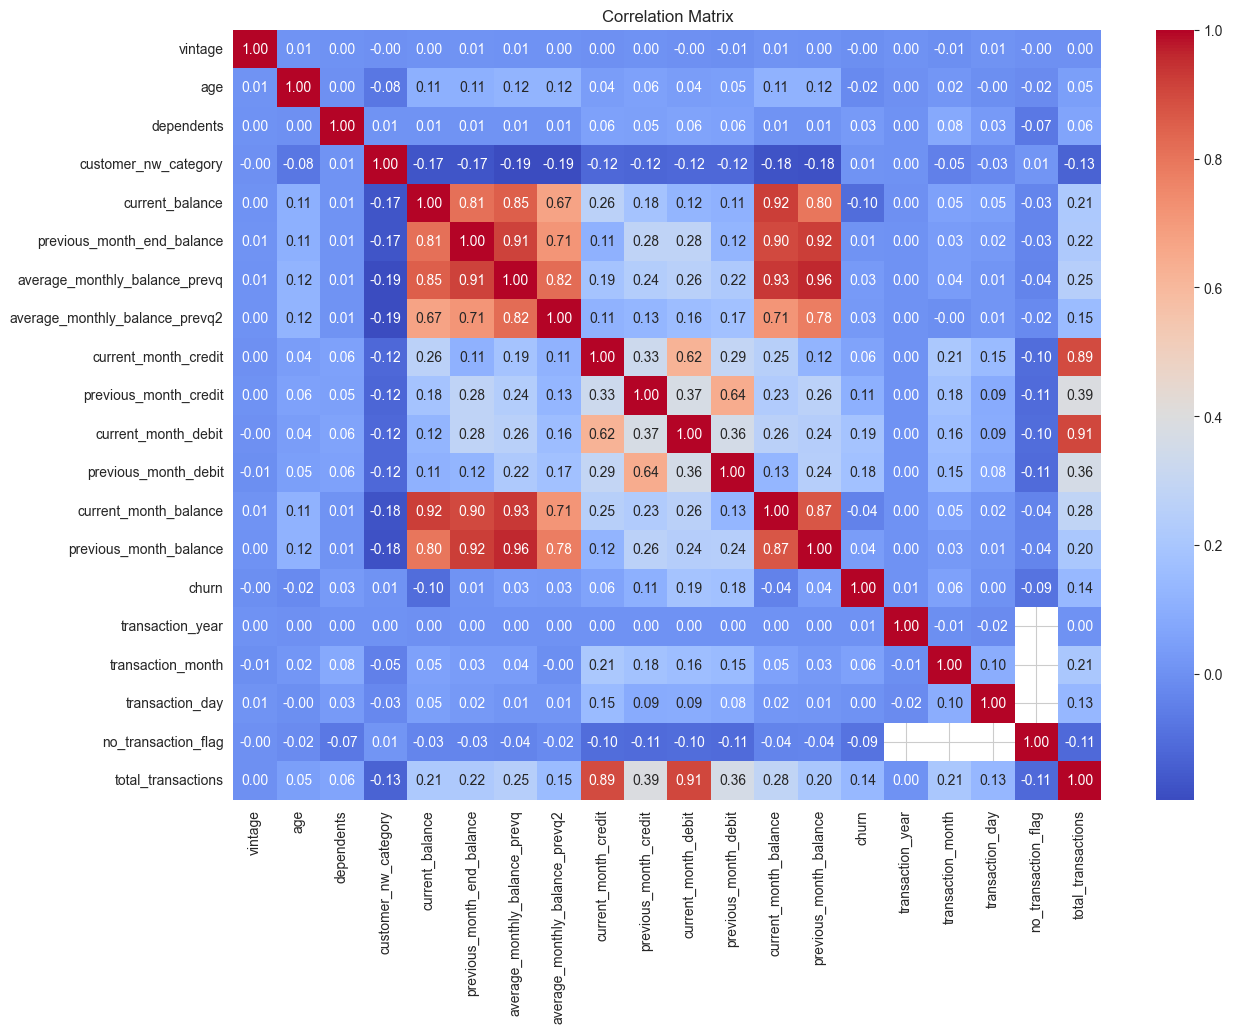

Top Numeric Correlations with Churn:
current_balance                  -0.105
no_transaction_flag              -0.085
current_month_balance            -0.041
age                              -0.020
vintage                          -0.005
transaction_day                   0.002
transaction_year                  0.005
previous_month_end_balance        0.006
customer_nw_category              0.007
average_monthly_balance_prevq2    0.027
dependents                        0.029
average_monthly_balance_prevq     0.033
previous_month_balance            0.043
transaction_month                 0.056
current_month_credit              0.058
previous_month_credit             0.108
total_transactions                0.137
previous_month_debit              0.178
current_month_debit               0.186
churn                             1.000
Name: churn, dtype: float64


In [11]:
# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print('Top Numeric Correlations with Churn:')
print(numeric_df.corr()['churn'].sort_values().round(3))



## 4. Key Insights

1. **Churn Rate:** Overall churn rate is **18.53%**, meaning nearly one in five customers leaves.
2. **Balance:** Lower balance customers churn more. The low-balance segment has the highest churn rate, making current balance a major risk signal.
3. **Gender:** Male customers show a slightly higher churn rate than female customers, so gender is useful for segmented retention analysis.
4. **Age Group:** Adult customers show the highest churn rate among the age groups in the cleaned dataset.
5. **Activity:** Higher transaction activity levels show higher churn in this dataset, especially high debit behavior. This may indicate customers moving money out before leaving.
6. **Occupation:** Self-employed customers have the highest churn rate among major occupation groups and behave differently from salaried, retired, student, and company customers.
7. **Business Focus:** The clearest retention focus areas are low-balance customers, customers with unusual/high debit activity, and self-employed customers.
